<div dir="rtl" style="text-align:right">

# 🧠 شبکه عصبی از صفر

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SharifiZarchi/IntroAI/blob/main/Session_07/NeuralNetworks/Neural_Networks_Tutorial_FA.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2FSharifiZarchi%2FIntroAI%2Fblob%2Fmain%2FSession_07%2FNeuralNetworks%2FNeural_Networks_Tutorial_FA.ipynb)

در این نوت‌بوک یک شبکه عصبی را گام‌به‌گام و بدون هیچ فریم‌ورکی پیاده‌سازی می‌کنیم، فقط با `numpy`. مسیر:

۱. نورون مصنوعی: جمع وزن‌دار + تابع فعال‌سازی

۲. نورون به‌عنوان دروازه منطقی، و محدودیتی که XOR آشکار می‌کند

۳. تابع فعال‌سازی سیگموید

۴. آموزش یک نورون با گرادیان کاهشی

۵. لایه پنهان و پس‌انتشار خطا

۶. دسته‌بندی ارقام دست‌نویس با `MLPClassifier`

۷. تحلیل شبکه آموزش‌دیده

۸. مقیاس بزرگ‌تر: دسته‌بندی CIFAR-10 با PyTorch

۹. جمع‌بندی و گام‌های بعدی

پیش‌نیازها از جلسات قبل: ویژگی و برچسب، تقسیم آموزش/آزمون، تابع هزینه، گرادیان کاهشی، نرخ یادگیری، بیش‌برازش. هر بخش با یک تمرین ✏️ تمام می‌شود. فایل داده لازم نیست؛ داده‌ها یا تولید می‌شوند یا همراه scikit-learn هستند.

**روش اجرا:** روی هر سلول کلیک کن و `Shift + Enter` بزن، به ترتیب از بالا به پایین.

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۱: نورون مصنوعی

نورون **جمع وزن‌دار ورودی‌ها به‌علاوه بایاس** را حساب می‌کند و سپس یک تابع فعال‌سازی روی آن اعمال می‌کند:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

در ساده‌ترین نسخه (مک‌کالک و پیتس، ۱۹۴۳) فعال‌سازی یک آستانه سخت است: اگر $z \ge 0$ خروجی ۱، وگرنه ۰.

- **وزن $w_i$**: سهم ورودی $i$ در تصمیم. می‌تواند منفی باشد (رأی مخالف).
- **بایاس $b$**: آستانه فعال‌شدن را جابه‌جا می‌کند. صورت‌بندی اسلایدها «اگر جمع وزن‌دار ≥ ۳ شلیک کن» معادل است با «اگر $z \ge 0$ شلیک کن» با $b = -3$.

تمام دانش آموخته‌شده شبکه در وزن‌ها و بایاس‌ها ذخیره می‌شود؛ آموزش یعنی یافتن مقادیر مناسب برای همین‌ها.

</div>

<div dir="rtl" style="text-align:right">

### ۱.۱ پیاده‌سازی
تصمیم پیک‌نیک اسلایدها (وزن‌های ۳ و ۲ و ۱ و آستانه ۳) به‌صورت کد:

</div>

In [1]:
def neuron(inputs, weights, bias):
    z = sum(w * x for w, x in zip(weights, inputs)) + bias
    return 1 if z >= 0 else 0

# ورودی‌ها: [آفتابی، تعطیلی، حوصله]، آستانه ۳ ← بایاس = ۳-
picnic_weights = [3, 2, 1]

print("آفتابی=۱، تعطیل=۰، حوصله=۱ ←", neuron([1, 0, 1], picnic_weights, bias=-3))
print("آفتابی=۰، تعطیل=۰، حوصله=۱ ←", neuron([0, 0, 1], picnic_weights, bias=-3))

آفتابی=۱، تعطیل=۰، حوصله=۱ ← 1
آفتابی=۰، تعطیل=۰، حوصله=۱ ← 0


<div dir="rtl" style="text-align:right">

حالت اول: z = ۳ + ۰ + ۱ − ۳ = ۱ ≥ ۰ ← خروجی ۱. حالت دوم: z = ۱ − ۳ = ۲- ← خروجی ۰. دقیقا همان محاسبه اسلاید.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱
ورودی چهارمی به نام `rainy` با وزن **منفی** اضافه کن، طوری که باران همیشه پیک‌نیک را لغو کند، حتی وقتی سه ورودی دیگر همگی ۱ هستند. اول روی کاغذ حداقل قدر لازم را حساب کن، بعد اعتبارسنجی کن:

</div>

In [3]:
picnic_weights_v2 = [3, 2, 1, -5]     # ✏️ صفر را با وزن باران عوض کن

print("بهترین روز + باران ←", neuron([1, 1, 1, 1], picnic_weights_v2, bias=-3))   # باید ۰ باشد
print("بهترین روز، بدون باران ←", neuron([1, 1, 1, 0], picnic_weights_v2, bias=-3))   # باید ۱ باشد

بهترین روز + باران ← 0
بهترین روز، بدون باران ← 1


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
picnic_weights_v2 = [3, 2, 1, -4]
```

حداکثر امتیاز سه ورودی دیگر ۳ + ۲ + ۱ = ۶ است و آستانه ۳؛ پس وزن باران باید در نامساوی ۶ + w < ۳ صدق کند، یعنی **w < ۳-**. هر مقدار ۴- یا کمتر درست است. این نسخه دستی همان کاری است که آموزش به‌صورت خودکار می‌کند: تنظیم وزن تا رفتار ورودی/خروجی درست شود.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۲: نورون به‌عنوان دروازه منطقی؛ محدودیت XOR

یک نورون تنها می‌تواند دروازه‌های منطقی پایه را پیاده کند؛ همان مشاهده ۱۹۴۳ که نشان می‌داد شبکه‌ای از نورون‌ها شاید بتواند توابع دلخواه را محاسبه کند. ابتدا کتابخانه‌های موردنیاز ادامه نوت‌بوک:

</div>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("کتابخانه‌ها آماده ✅")

کتابخانه‌ها آماده ✅


<div dir="rtl" style="text-align:right">

### ۲.۱ دروازه AND
خروجی AND فقط وقتی ۱ است که هر دو ورودی ۱ باشند. وزن‌های (۱، ۱) و بایاس ۱.۵- آن را می‌سازند: فقط ۱ + ۱ − ۱.۵ مثبت است.

</div>

In [5]:
def and_neuron(x1, x2):
    z = 1*x1 + 1*x2 - 1.5
    return 1 if z > 0 else 0

for x1, x2 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    print(f"{x1} AND {x2}  →  {and_neuron(x1, x2)}")

0 AND 0  →  0
0 AND 1  →  0
1 AND 0  →  0
1 AND 1  →  1


<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۲
مقادیر `w1`، `w2` و `b` را طوری تعیین کن که دروازه **OR** ساخته شود (خروجی ۱ اگر دست‌کم یکی از ورودی‌ها ۱ باشد). حلقه زیر هر چهار حالت را بررسی می‌کند:

</div>

In [9]:
w1, w2, b = 2, 3, -.5        # ✏️ مقداردهی کن

def or_neuron(x1, x2):
    return 1 if w1*x1 + w2*x2 + b > 0 else 0

for x1, x2 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    target = 1 if (x1 == 1 or x2 == 1) else 0
    out = or_neuron(x1, x2)
    print(f"{x1} OR {x2}  →  {out}   {'✅' if out == target else '❌'}")

0 OR 0  →  0   ✅
0 OR 1  →  1   ✅
1 OR 0  →  1   ✅
1 OR 1  →  1   ✅


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
w1, w2, b = 1, 1, -0.5
```

با بایاس ۰.۵-، یک ورودی فعال (z = ۰.۵) نورون را فعال می‌کند ولی هیچ ورودی فعال (z = ۰.۵-) نه. توجه کن که AND و OR **فقط در بایاس** تفاوت دارند (۱.۵- در برابر ۰.۵-). بی‌نهایت جواب دیگر هم وجود دارد، مثلا `2, 3, -1`.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ۲.۲ محدودیت: XOR
خروجی **XOR** دقیقا وقتی ۱ است که ورودی‌ها متفاوت باشند: (۰,۱) و (۱,۰). چهار حالت را در صفحه ورودی رسم کنیم:

</div>

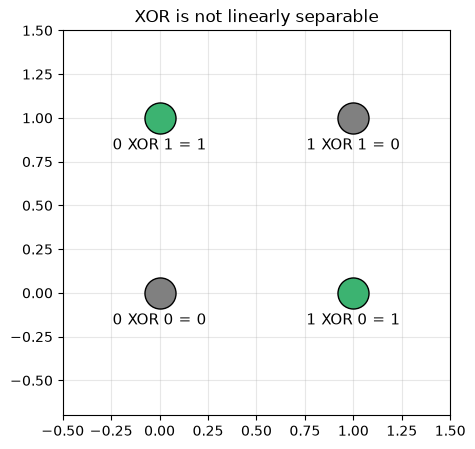

In [10]:
points = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels = np.array([0, 1, 1, 0])

plt.figure(figsize=(5, 5))
for (x1, x2), lab in zip(points, labels):
    color = "mediumseagreen" if lab == 1 else "gray"
    plt.scatter(x1, x2, s=500, color=color, edgecolor="black", zorder=3)
    plt.text(x1, x2 - 0.18, f"{x1} XOR {x2} = {lab}", ha="center", fontsize=11)
plt.xlim(-0.5, 1.5); plt.ylim(-0.7, 1.5)
plt.title("XOR is not linearly separable")
plt.grid(alpha=0.3)
plt.show()

<div dir="rtl" style="text-align:right">

شرط $z = w_1 x_1 + w_2 x_2 + b \ge 0$ یک نیم‌صفحه تعریف می‌کند: مرز تصمیم یک نورون تنها همیشه **یک خط راست** است. دو کلاس XOR روی دو قطر مقابل نشسته‌اند، پس هیچ خطی نمی‌تواند هر دو نقطه سبز را یک طرف و هر دو خاکستری را طرف دیگر بگذارد. پس یک نورون تنها، با هر وزنی، **قادر به نمایش XOR نیست**.

یادداشت تاریخی: مینسکی و پپرت این محدودیت را در کتاب *Perceptrons* (سال ۱۹۶۹) منتشر کردند. این نتیجه در افت بودجه و علاقه به این حوزه نقش داشت: همان «زمستان اول هوش مصنوعی»، حدود یک دهه رکود در تحقیقات شبکه عصبی. راه‌حل (بخش ۵) کنار هم گذاشتن نورون‌ها در لایه‌هاست؛ اما قبل از آن باید تابع فعال‌سازی را ارتقا دهیم، چون آستانه سخت با آموزش گرادیانی سازگار نیست.

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۳: تابع فعال‌سازی سیگموید

گرادیان کاهشی هر وزن را با این پرسش تنظیم می‌کند: اگر این وزن کمی تغییر کند، تابع هزینه چقدر تغییر می‌کند؟ این یعنی خروجی باید **پیوسته** با وزن‌ها تغییر کند. با آستانه سخت، خروجی قطعه‌ای‌ثابت است: مشتقش تقریبا همه‌جا صفر است و گرادیان هیچ اطلاعاتی حمل نمی‌کند.

راه‌حل استاندارد، فعال‌سازی هموار است. **سیگموید**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

</div>

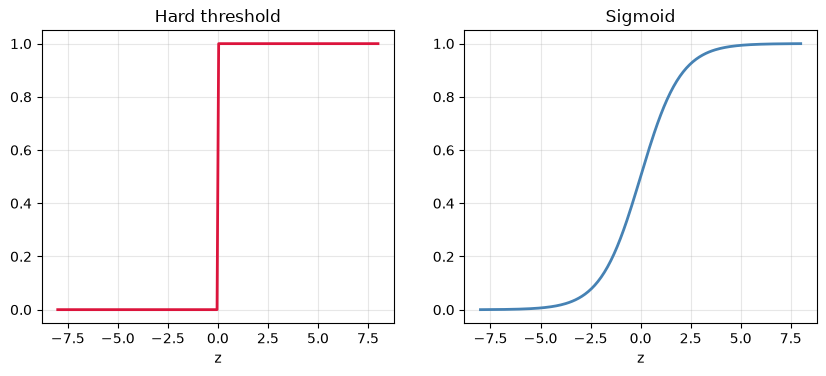

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
ax1.plot(z, (z > 0).astype(float), color="crimson", linewidth=2)
ax1.set_title("Hard threshold")
ax1.set_xlabel("z"); ax1.grid(alpha=0.3)
ax2.plot(z, sigmoid(z), color="steelblue", linewidth=2)
ax2.set_title("Sigmoid")
ax2.set_xlabel("z"); ax2.grid(alpha=0.3)
plt.show()

<div dir="rtl" style="text-align:right">

ویژگی‌های مهم در این‌جا:

- همه‌جا مشتق‌پذیر است، با مشتق فشرده $\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$ که در بخش ۵ استفاده می‌شود.
- خروجی در بازه (۰، ۱) است و به‌صورت **احتمال کلاس** تفسیر می‌شود، مثل `predict_proba` در جلسه ۵.
- یکنواست: z بزرگ‌تر همچنان یعنی پاسخ قوی‌تر «۱»، پس شهود آستانه حفظ می‌شود.

شبکه‌های عمیق امروزی در لایه‌های پنهان بیشتر از **ReLU** ($\max(0, z)$) استفاده می‌کنند (ارزان‌تر و در شبکه‌های بسیار عمیق خوش‌رفتارتر)، اما سیگموید برای اولین پیاده‌سازی شفاف‌ترین انتخاب است و برای خروجی دودویی همچنان استاندارد است.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۳
قبل از اجرای سلول، مقادیر `sigmoid(0)`، `sigmoid(5)`، `sigmoid(-5)` و `sigmoid(100)` را پیش‌بینی کن. یکی از چهار نتیجه از نظر تحلیلی غلط است. کدام و چرا؟

</div>

In [12]:
# ✏️ اول پیش‌بینی کن، بعد اجرا
for value in [0, 5, -5, 100]:
    print(f"sigmoid({value}) =", sigmoid(value))

sigmoid(0) = 0.5
sigmoid(5) = 0.9933071490757153
sigmoid(-5) = 0.0066928509242848554
sigmoid(100) = 1.0


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

`sigmoid(0) = 0.5`، `sigmoid(5) ≈ 0.9933`، `sigmoid(-5) ≈ 0.0067`، مطابق نمودار.

`sigmoid(100)` عدد `1.0` چاپ می‌کند که از نظر تحلیلی غلط است: برای هر z متناهی $\sigma(z) < 1$. مقدار واقعی $1 - 3.7\times10^{-44}$ است و این فاصله از دقت اعشار ۶۴ بیتی (حدود $10^{-16}$ در نزدیکی ۱) کوچک‌تر است، پس به ۱.۰ گرد می‌شود. نکته ماندنی: گردکردن ممیز شناور بی‌سروصدا مقادیر حدی را تغییر می‌دهد.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۴: آموزش یک نورون با گرادیان کاهشی

صورت مسئله: دسته‌بندی دودویی با دو ویژگی (۲۰۰ نمونه، دو خوشه گاوسی). یک نورون سیگمویدی با وزن‌های $w = (w_1, w_2)$ و بایاس $b$ باید مرز دو کلاس را یاد بگیرد.

</div>

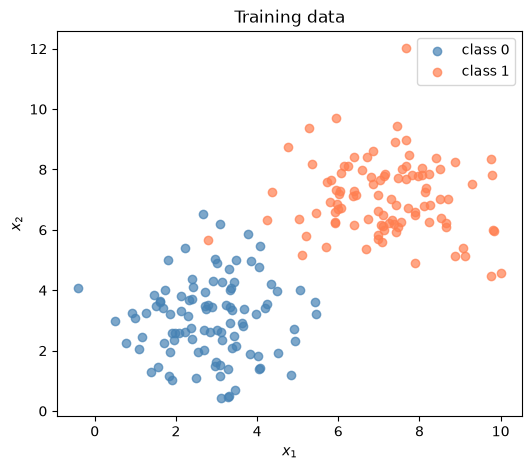

In [13]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, centers=[[3, 3], [7, 7]],
                  cluster_std=1.3, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="steelblue", alpha=0.7, label="class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="coral", alpha=0.7, label="class 1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Training data")
plt.legend(); plt.show()

<div dir="rtl" style="text-align:right">

### ۴.۱ تابع هزینه: آنتروپی متقاطع
در جلسه‌های ۳ و ۴ خطا را با MAE و MSE اندازه گرفتیم که برای رگرسیون مناسب‌اند: فاصله دو عدد. این‌جا خروجی مدل یک **احتمال** است و تابع هزینه استاندارد برای احتمال‌ها **آنتروپی متقاطع (Cross-Entropy)** است. برای یک نمونه با برچسب $y \in \{0, 1\}$ و احتمال پیش‌بینی‌شده $a$:

$$L = -\left[\, y \ln a + (1-y)\ln(1-a) \,\right]$$

برای هر نمونه فقط یکی از دو جمله فعال است: اگر $y=1$ هزینه $-\ln a$ است و اگر $y=0$ هزینه $-\ln(1-a)$. به بیان ساده: **جریمه برابر است با منفی لگاریتم احتمالی که مدل به جواب درست داده است.** رسم این جریمه رفتارش را نشان می‌دهد:

</div>

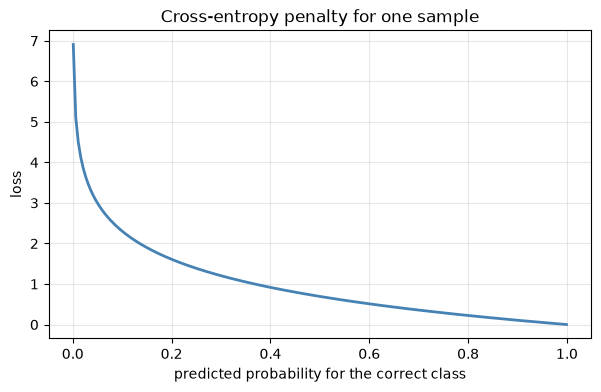

In [14]:
a = np.linspace(0.001, 0.999, 200)

plt.figure(figsize=(7, 4))
plt.plot(a, -np.log(a), color="steelblue", linewidth=2)
plt.xlabel("predicted probability for the correct class")
plt.ylabel("loss")
plt.title("Cross-entropy penalty for one sample")
plt.grid(alpha=0.3)
plt.show()

<div dir="rtl" style="text-align:right">

خواندن نمودار: احتمال ۰.۹ برای کلاس درست تقریبا هزینه‌ای ندارد؛ احتمال ۰.۱ هزینه سنگینی دارد و با نزدیک‌شدن احتمال به صفر، هزینه بی‌کران رشد می‌کند. آنتروپی متقاطع **جواب غلط همراه با اطمینان** را به‌شدت جریمه می‌کند؛ دقیقا همان انگیزه‌ای که یک دسته‌بند احتمال‌ساز لازم دارد. (MSE هم این‌جا کار می‌کند، اما با سیگموید زوج خوبی نیست: برای نورون اشباع‌شده‌ای که خیلی غلط می‌گوید، گرادیان MSE تقریبا صفر می‌شود و یادگیری می‌ایستد. آنتروپی متقاطع گرادیان را قوی نگه می‌دارد؛ در بخش بعد می‌بینیم.)

</div>

<div dir="rtl" style="text-align:right">

### ۴.۲ قاعده به‌روزرسانی
گذر رو به جلو: $a = \sigma(w \cdot x + b)$، به‌عنوان احتمال پیش‌بینی‌شده کلاس ۱. با این تابع هزینه، گرادیان‌ها شکل فشرده‌ای پیدا می‌کنند (اثبات در بخش بازشو):

$$\frac{\partial L}{\partial w_i} = (a - y)\,x_i \qquad \frac{\partial L}{\partial b} = (a - y)$$

عامل $(a - y)$ همان خطای پیش‌بینی است. پس هر گام گرادیان کاهشی، میانگین‌گیری‌شده روی داده‌ها:

$$w \leftarrow w - \eta \cdot \overline{(a - y)\,x} \qquad b \leftarrow b - \eta \cdot \overline{(a - y)}$$

با نرخ یادگیری $\eta$، دقیقا طبق تعریف جلسه ۴. به ساختار گرادیان توجه کن: **خطا × ورودی**: وزنی اصلاح بزرگ می‌گیرد که ورودی‌اش بزرگ بوده و پیش‌بینی غلط بوده است.

<details>
<summary>🔍 اثبات</summary>

با $a = \sigma(z)$ و $z = w \cdot x + b$ و هزینه آنتروپی متقاطع $L = -[y \ln a + (1-y)\ln(1-a)]$، قاعده زنجیره‌ای می‌دهد:

$$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial a} \cdot \sigma'(z) = \frac{a - y}{a(1-a)} \cdot a(1-a) = a - y$$

و $\partial z / \partial w_i = x_i$. مشتق سیگموید با مشتق هزینه ساده می‌شود؛ دلیل استانداردبودن زوج سیگموید + آنتروپی متقاطع همین است.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ۴.۳ پیاده‌سازی
حلقه آموزش، برداری‌شده با `X @ w` (ضرب ماتریسی: جمع وزن‌دار هر ۲۰۰ نمونه یک‌جا). از وزن‌های اولیه عمدا نامناسب شروع می‌کنیم و مرز تصمیم را در ایپاک‌های ۰، ۵، ۳۰ و ۲۰۰ ثبت می‌کنیم:

</div>

In [15]:
w = np.array([-1.0, 1.0])       # وزن اولیه عمدا نامناسب
b = 0.0
learning_rate = 0.5

losses = []
snapshots = {0: (w.copy(), b)}

for epoch in range(1, 201):
    a = sigmoid(X @ w + b)                       # گذر رو به جلو، همه نمونه‌ها
    error = a - y                                # dL/dz برای هر نمونه
    w = w - learning_rate * (X.T @ error) / len(X)   # dL/dw میانگین‌گیری‌شده
    b = b - learning_rate * error.mean()             # dL/db
    losses.append(np.abs(error).mean())          # میانگین |خطا| برای منحنی هزینه
    if epoch in (5, 30, 200):
        snapshots[epoch] = (w.copy(), b)

accuracy = ((a > 0.5).astype(int) == y).mean()
print("دقت بعد از ۲۰۰ ایپاک:", round(accuracy, 3))
print("میانگین |خطا|:", round(losses[0], 3), "←", round(losses[-1], 3))

دقت بعد از ۲۰۰ ایپاک: 0.995
میانگین |خطا|: 0.524 ← 0.085


<div dir="rtl" style="text-align:right">

دقت ۹۹.۵٪ فقط از بازخورد خطا. مرز تصمیم، خط $w_1 x_1 + w_2 x_2 + b = 0$ است؛ حرکتش در طول آموزش:

</div>

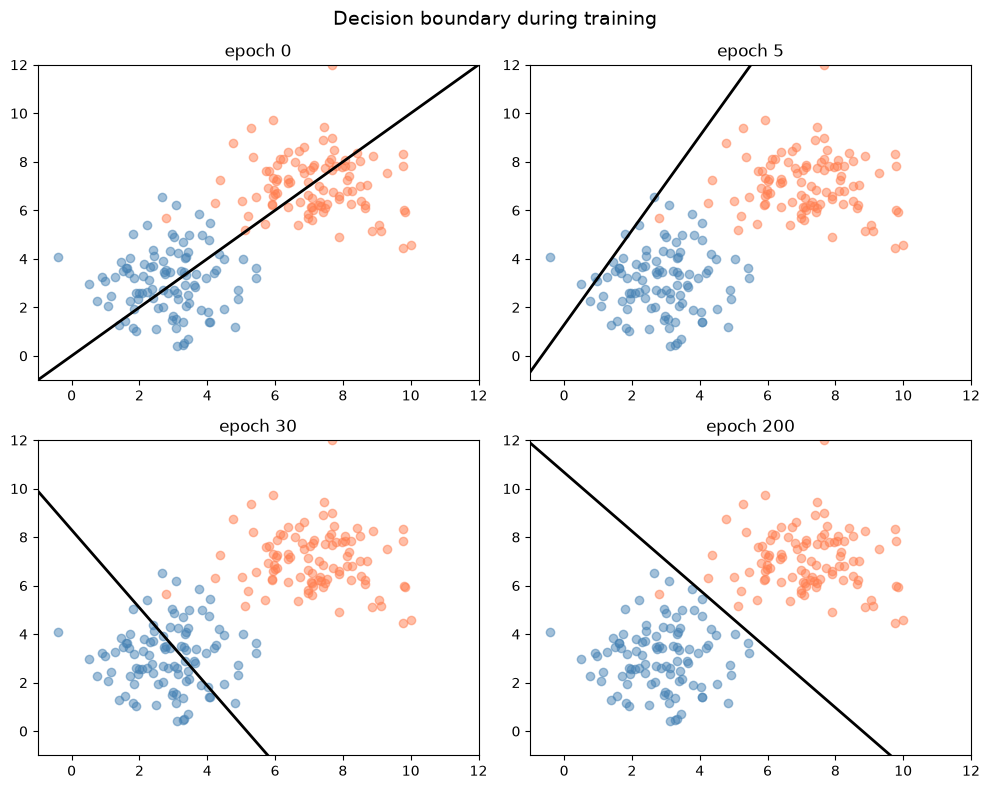

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (epoch, (ws, bs)) in zip(axes.ravel(), snapshots.items()):
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color="steelblue", alpha=0.5)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color="coral", alpha=0.5)
    xs = np.array([-1.0, 12.0])
    ax.plot(xs, -(ws[0]*xs + bs) / ws[1], "k-", linewidth=2)
    ax.set_xlim(-1, 12); ax.set_ylim(-1, 12)
    ax.set_title(f"epoch {epoch}")
plt.suptitle("Decision boundary during training", fontsize=14)
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

در ایپاک ۰ مرز از میان هر دو خوشه می‌گذرد؛ تا ایپاک ۲۰۰ آن‌ها را جدا کرده است. منحنی هزینه همین اجرا:

</div>

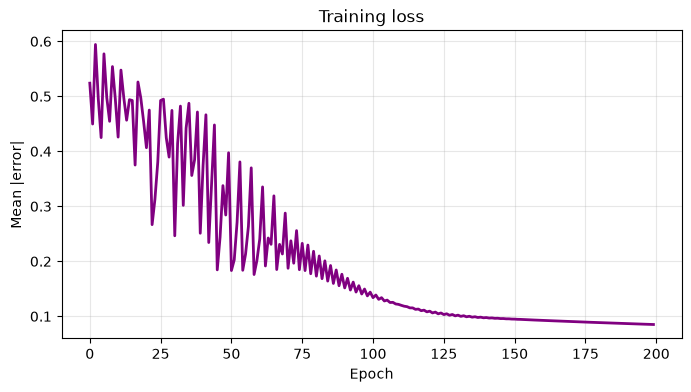

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color="purple", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Mean |error|")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.show()

<div dir="rtl" style="text-align:right">

این همان پایین‌رفتن روی سطح هزینه از جلسه ۴ است، این‌بار اندازه‌گیری‌شده روی یک اجرای واقعی: هر ایپاک یک گام گرادیان است و منحنی، هزینه حاصل را دنبال می‌کند. منحنی آموزش هر شبکه عصبی‌ای در اساس گونه‌ای از همین نمودار است.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۴
اجرا را با نرخ‌های یادگیری **۰.۰۱** و **۲۰** (اضافه‌شده به لیست) تکرار کن و سه منحنی هزینه را مقایسه کن. هر کدام را به بحث جلسه ۴ درباره اندازه گام ربط بده (خیلی کوچک ← همگرایی کند؛ خیلی بزرگ ← نوسان).

</div>

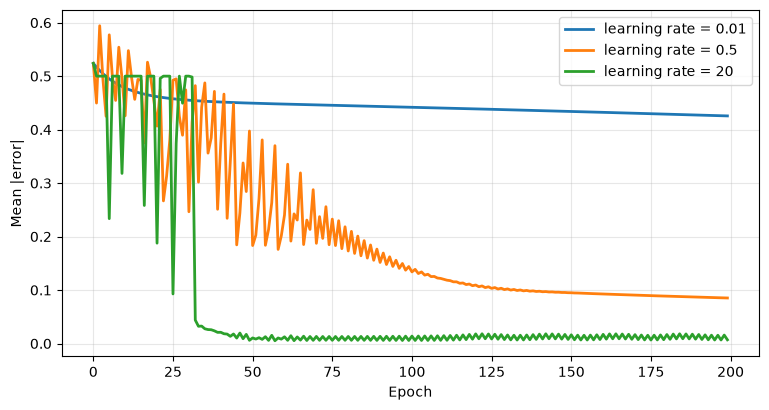

In [18]:
plt.figure(figsize=(9, 4.5))

for lr in [0.01, 0.5, 20]:                       # ✏️ تبدیلش کن به [0.01, 0.5, 20]
    w_try, b_try = np.array([-1.0, 1.0]), 0.0
    losses_try = []
    for _ in range(200):
        error = sigmoid(X @ w_try + b_try) - y
        w_try = w_try - lr * (X.T @ error) / len(X)
        b_try = b_try - lr * error.mean()
        losses_try.append(np.abs(error).mean())
    plt.plot(losses_try, linewidth=2, label=f"learning rate = {lr}")

plt.xlabel("Epoch"); plt.ylabel("Mean |error|")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
for lr in [0.01, 0.5, 20]:
```

- **۰.۰۱**: بعد از ۲۰۰ ایپاک هزینه هنوز نزدیک مقدار اولیه است؛ همگرایی بیش از حد کند.
- **۰.۵**: همگرایی هموار و سریع.
- **۲۰**: نوسان شدید؛ بردار پارامترها مدام از روی کمینه می‌پرد. روی این داده آسان خطی‌جداپذیر در نهایت به ناحیه خوب می‌رسد، اما در مسائل سخت‌تر چنین اجرایی اغلب واگرا می‌شود. در عمل، نرخ یادگیری یکی از مهم‌ترین ابرپارامترهای قابل‌تنظیم است.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۵: لایه پنهان و پس‌انتشار خطا

داده‌ای که در آن مرز خطی اثباتا ناکافی است: دو حلقه هم‌مرکز (همان داده «دایره‌ای» playground.tensorflow.org که در اسلاید آخر آمده):

</div>

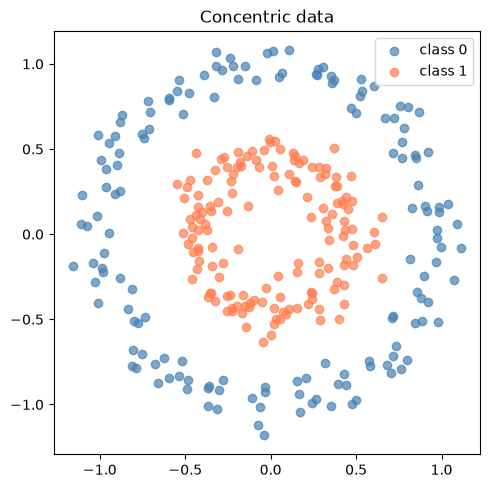

In [19]:
from sklearn.datasets import make_circles

X2, y2 = make_circles(n_samples=300, factor=0.45, noise=0.08, random_state=42)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], color="steelblue", alpha=0.7, label="class 0")
plt.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], color="coral", alpha=0.7, label="class 1")
plt.title("Concentric data")
plt.legend(); plt.show()

<div dir="rtl" style="text-align:right">

### ۵.۱ خط پایه: شکست نورون تنها
۵۰۰ ایپاک، ۲.۵ برابر آن‌چه بخش ۴ لازم داشت:

</div>

In [20]:
w, b = np.array([-1.0, 1.0]), 0.0
for epoch in range(500):
    error = sigmoid(X2 @ w + b) - y2
    w = w - 0.5 * (X2.T @ error) / len(X2)
    b = b - 0.5 * error.mean()

accuracy = ((sigmoid(X2 @ w + b) > 0.5).astype(int) == y2).mean()
print("نورون تنها، ۵۰۰ ایپاک، دقت:", round(accuracy, 3))

نورون تنها، ۵۰۰ ایپاک، دقت: 0.5


<div dir="rtl" style="text-align:right">

دقیقا ۰.۵، یعنی در حد شانس. این محدودیت نمایش است، نه مشکل آموزش: هیچ خطی یک قرص را از حلقه دورش جدا نمی‌کند، همان‌طور که هیچ خطی XOR را جدا نمی‌کرد. یک تابع کمکی برای نمایش نواحی تصمیم (ارزیابی پیش‌بینی روی یک شبکه نقاط) که پایین‌تر هم استفاده می‌شود:

</div>

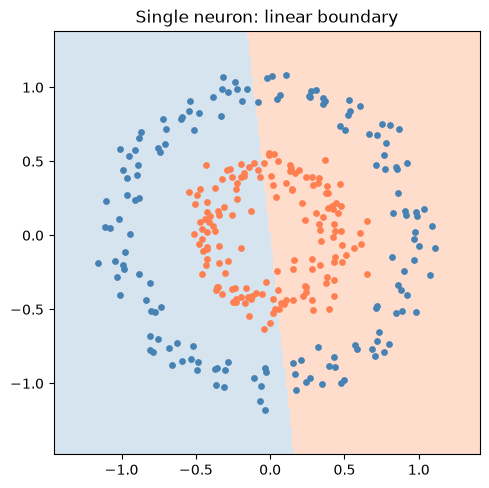

In [21]:
def plot_boundary(predict, X, y, title=""):
    gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 200),
                         np.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 200))
    grid = np.c_[gx.ravel(), gy.ravel()]
    zz = predict(grid).reshape(gx.shape)
    plt.contourf(gx, gy, zz, levels=[-0.5, 0.5, 1.5], colors=["#d6e4f0", "#ffddcc"])
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color="steelblue", s=15)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color="coral", s=15)
    plt.title(title)

plt.figure(figsize=(5.5, 5.5))
plot_boundary(lambda G: (sigmoid(G @ w + b) > 0.5).astype(int), X2, y2,
              "Single neuron: linear boundary")
plt.show()

<div dir="rtl" style="text-align:right">

### ۵.۲ معماری دولایه
راه‌حل، ترکیب است. یک **لایه پنهان** با ۴ نورون، هر کدام سیگموید یک تابع خطی از ورودی‌ها را حساب می‌کند؛ سپس یک **نورون خروجی** سیگموید یک تابع خطی از همان ۴ فعال‌سازی پنهان را:

$$H = \sigma(X W_1 + b_1) \qquad \hat{y} = \sigma(H W_2 + b_2)$$

ماتریس $W_1$ ابعاد ۲×۴ دارد (ورودی ← پنهان) و $W_2$ ابعاد ۴×۱ (پنهان ← خروجی). ساختار تصمیم هر نورون پنهان همچنان خطی است، اما نورون خروجی روی *فعال‌سازی‌های پنهان* عمل می‌کند نه ورودی خام، و ترکیب وزن‌دار چند مرز خطی نرم می‌تواند ناحیه‌های خمیده و بسته توصیف کند.

برای آموزش، گرادیان **همه** وزن‌ها لازم است. خطای لایه خروجی مستقیم معلوم است ($\hat{y} - y$، مثل بخش ۴)؛ پرسش این است که چه سهمی از آن به هر نورون پنهان می‌رسد. **پس‌انتشار خطا** (رایج‌شده در ۱۹۸۶؛ نتیجه‌ای که رشته را از زمستان بخش ۲ بیرون آورد) با قاعده زنجیره‌ای جواب می‌دهد: خطای خروجی را از همان وزن‌های $W_2$ که در گذر رو به جلو استفاده شدند به عقب منتشر کن، ضرب در مشتق سیگموید هر نورون پنهان:

$$\delta_{out} = \hat{y} - y \qquad \delta_{hidden} = (\delta_{out} W_2^{\top}) \odot H(1 - H)$$

سپس هر لایه دقیقا مثل بخش ۴ به‌روزرسانی می‌شود: گرادیان = (ورودی آن لایه)ᵀ × (δ آن لایه)، میانگین‌گیری‌شده روی نمونه‌ها.

</div>

<div dir="rtl" style="text-align:right">

### ۵.۳ پیاده‌سازی
شبکه کامل: گذر رو به جلو، پس‌انتشار، گام گرادیان:

</div>

In [22]:
def train_network(X, y, hidden=4, learning_rate=2.0, epochs=4000, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 1, (X.shape[1], hidden))   # وزن‌های ورودی ← پنهان
    b1 = np.zeros(hidden)
    W2 = rng.normal(0, 1, (hidden, 1))            # وزن‌های پنهان ← خروجی
    b2 = np.zeros(1)
    y_col = y.reshape(-1, 1)
    losses = []

    for epoch in range(epochs):
        # گذر رو به جلو
        H = sigmoid(X @ W1 + b1)                  # فعال‌سازی‌های پنهان
        out = sigmoid(H @ W2 + b2)                # احتمال خروجی

        # پس‌انتشار خطا
        delta_out = out - y_col                              # dL/dz در خروجی
        delta_hidden = (delta_out @ W2.T) * H * (1 - H)      # dL/dz در لایه پنهان

        # گام گرادیان کاهشی (گرادیان = ورودیᵀ @ delta، میانگین‌گیری‌شده)
        W2 -= learning_rate * (H.T @ delta_out) / len(X)
        b2 -= learning_rate * delta_out.mean(0)
        W1 -= learning_rate * (X.T @ delta_hidden) / len(X)
        b1 -= learning_rate * delta_hidden.mean(0)

        losses.append(np.abs(delta_out).mean())

    return (W1, b1, W2, b2), losses


def predict_network(params, X):
    W1, b1, W2, b2 = params
    H = sigmoid(X @ W1 + b1)
    return (sigmoid(H @ W2 + b2)[:, 0] > 0.5).astype(int)

print("پیاده‌سازی شبکه کامل شد ✅")

پیاده‌سازی شبکه کامل شد ✅


<div dir="rtl" style="text-align:right">

### ۵.۴ نتیجه روی داده هم‌مرکز

</div>

شبکه با ۴ نورون پنهان: 1.0


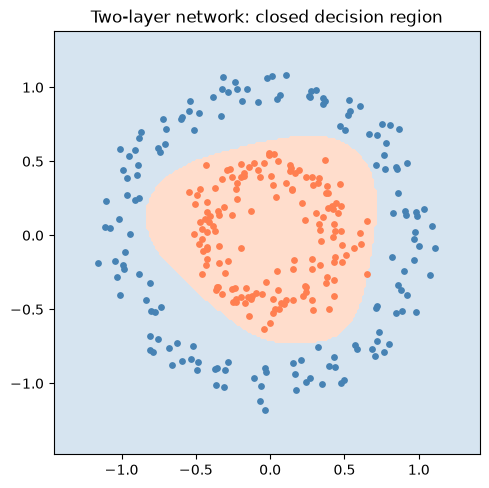

In [23]:
params, losses_net = train_network(X2, y2, hidden=4)

accuracy = (predict_network(params, X2) == y2).mean()
print("شبکه با ۴ نورون پنهان:", round(accuracy, 3))

plt.figure(figsize=(5.5, 5.5))
plot_boundary(lambda G: predict_network(params, G), X2, y2,
              "Two-layer network: closed decision region")
plt.show()

<div dir="rtl" style="text-align:right">

از ۰.۵ به ۱.۰، و ناحیه تصمیم یک منحنی بسته است؛ برای هر نورون تنها ناممکن. برای دیدن سازوکار، فعال‌سازی هر نورون پنهان را روی صفحه ورودی رسم می‌کنیم:

</div>

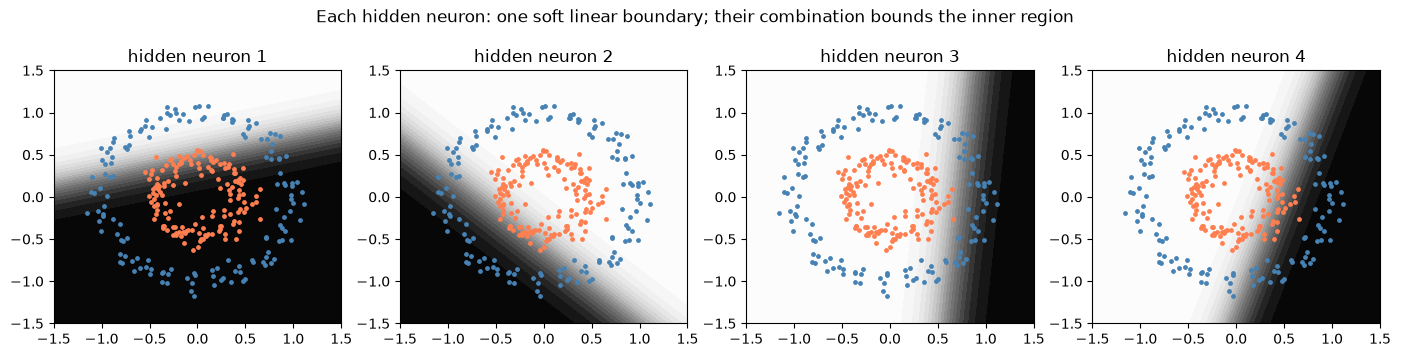

In [24]:
W1, b1, W2, b2 = params
gx, gy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
H_grid = sigmoid(np.c_[gx.ravel(), gy.ravel()] @ W1 + b1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for j, ax in enumerate(axes):
    ax.contourf(gx, gy, H_grid[:, j].reshape(gx.shape), levels=20, cmap="Greys")
    ax.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], color="steelblue", s=6)
    ax.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], color="coral", s=6)
    ax.set_title(f"hidden neuron {j + 1}")
plt.suptitle("Each hidden neuron: one soft linear boundary; their combination bounds the inner region", fontsize=12)
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

هر نورون پنهان یک نیم‌صفحه نرم در جهتی متفاوت یاد گرفته است. ترکیب وزن‌دار این چهار نیم‌صفحه در نورون خروجی، ناحیه بسته را می‌سازد. این کوچک‌ترین نمونه کامل همان ایده «انتزاع لایه‌به‌لایه» اسلایدها (ورودی خام ← ویژگی‌های میانی ← تصمیم). جهت‌گیری هیچ نورونی از پیش تعیین نشده بود؛ همه صرفا از پس‌انتشار به دست آمد.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۵: آزمون XOR
متغیرهای `points` و `labels` بخش ۲ هنوز در حافظه‌اند. `train_network` را رویشان آموزش بده و پیش‌بینی‌ها را کنار برچسب‌ها چاپ کن تا تحقق‌پذیری تابعی که برای نورون تنها اثباتا ناممکن بود، با شبکه دولایه بررسی شود.

</div>

In [25]:
# ✏️ شبکه را روی نقاط XOR آموزش بده
# (راهنمایی: اول train_network(...)، بعد predict_network(...))
params_xor, _ = train_network(points.astype(float), labels, hidden=4)

print('prediction: ', predict_network(params_xor, points.astype(float)))
print('labels: ',labels)



prediction:  [0 1 1 0]
labels:  [0 1 1 0]


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
params_xor, _ = train_network(points.astype(float), labels, hidden=4)

print("پیش‌بینی:", predict_network(params_xor, points.astype(float)))
print("برچسب‌ها: ", labels)
```

خروجی `[0 1 1 0]` دقیقا همان XOR است، آموخته‌شده از چهار نمونه‌اش. `hidden=1` را هم امتحان کن: در آن حالت شبکه عملا به یک مرز خطی کاهش می‌یابد و شکست می‌خورد، سازگار با بخش ۲. دو نورون پنهان حداقل نظری برای XOR است؛ چهار نورون از مقداردهی تصادفی به‌طور قابل‌اتکا همگرا می‌شود.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۶: دسته‌بندی ارقام دست‌نویس

یک مسئله واقعی در مقیاس کوچک: scikit-learn شامل ۱۷۹۷ رقم دست‌نویس به‌صورت تصویرهای ۸×۸ خاکستری است (خویشاوند فشرده مجموعه کلاسیک MNIST که در خواندن کدپستی و چک بانکی استفاده می‌شد):

</div>

تعداد نمونه‌ها: 1797 | ابعاد تصویر: (8, 8)


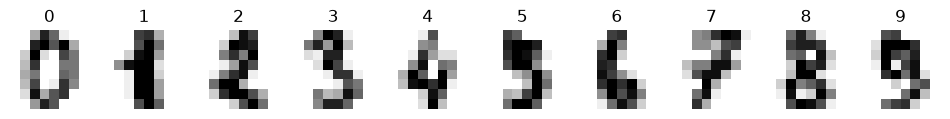

In [26]:
from sklearn.datasets import load_digits

digits = load_digits()
print("تعداد نمونه‌ها:", len(digits.images), "| ابعاد تصویر:", digits.images[0].shape)

fig, axes = plt.subplots(1, 10, figsize=(12, 1.7))
for ax, img, lab in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(lab); ax.axis("off")
plt.show()

<div dir="rtl" style="text-align:right">

### ۶.۱ تصویر به‌عنوان بردار ویژگی
برای مدل، تصویر ماتریسی از مقادیر شدت است (۰ = زمینه، ۱۶ = حداکثر جوهر):

</div>

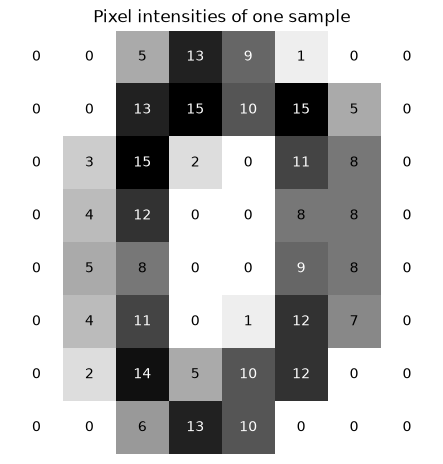

In [27]:
img = digits.images[0]

plt.figure(figsize=(5.5, 5.5))
plt.imshow(img, cmap="gray_r")
for i in range(8):
    for j in range(8):
        plt.text(j, i, int(img[i, j]), ha="center", va="center",
                 color="white" if img[i, j] > 8 else "black")
plt.title("Pixel intensities of one sample")
plt.axis("off"); plt.show()

<div dir="rtl" style="text-align:right">

تخت‌کردن ماتریس ۸×۸ یک بردار با **۶۴ ویژگی** می‌دهد؛ از این‌جا به بعد، دسته‌بندی رقم از نظر ساختاری همان مسئله بخش ۴ است، با ۶۴ ورودی به‌جای ۲. همین تبدیل تصویر به بردار ویژگی، نقطه ورود کل بینایی ماشین است.

### ۶.۲ `MLPClassifier`
معماری موردنیاز: ۶۴ ورودی ← ۳۲ نورون پنهان ← **۱۰ خروجی** (یکی به ازای هر کلاس، با softmax، تعمیم سیگموید، که یک توزیع احتمال روی ۱۰ رقم می‌دهد). به‌جای گسترش پیاده‌سازی numpy، از `MLPClassifier` در scikit-learn استفاده می‌کنیم که از نظر الگوریتمی همان گذر رو به جلو / پس‌انتشار / گام گرادیان `train_network` است با بهینه‌سازی صنعتی. رابطش همان `fit.` و `score.` جلسات قبل است:

</div>

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42)

mlp = MLPClassifier(hidden_layer_sizes=(32,), max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)

n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
print("دقت آزمون:", round(mlp.score(X_test, y_test), 3))
print("تعداد پارامترهای قابل‌آموزش:", n_params)

دقت آزمون: 0.978
تعداد پارامترهای قابل‌آموزش: 2410


<div dir="rtl" style="text-align:right">

حدود ۹۸٪ روی ارقام دیده‌نشده، با **۲۴۱۰ پارامتر** (وزن‌های ۳۲×۶۴ و ۱۰×۳۲ به‌علاوه ۴۲ بایاس) که همگی با همان قاعده گرادیانی بخش ۵ تنظیم شده‌اند. احتمالات هر کلاس برای یک نمونه آزمون:

</div>

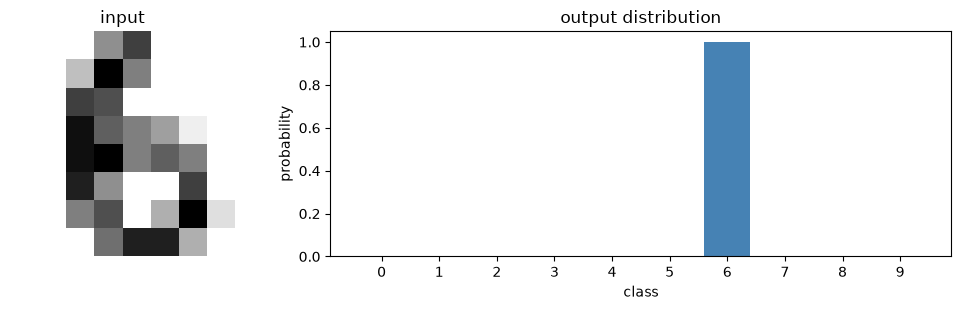

In [29]:
sample = X_test[0]
probabilities = mlp.predict_proba([sample])[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2), width_ratios=[1, 2.2])
ax1.imshow(sample.reshape(8, 8), cmap="gray_r"); ax1.axis("off")
ax1.set_title("input")
ax2.bar(range(10), probabilities, color="steelblue")
ax2.set_xticks(range(10)); ax2.set_xlabel("class"); ax2.set_ylabel("probability")
ax2.set_title("output distribution")
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۶: ظرفیت در برابر دقت
آموزش را با لایه‌های پنهان **۲** و **۸** نورونی تکرار کن و دقت آزمون را مقایسه کن. قبل از اجرا فرضیه بساز: با ۲ نورون پنهان، کل اطلاعات ۶۴ پیکسل باید از ۲ فعال‌سازی عبور کند. چقدر از دقت از این گلوگاه عبور می‌کند؟

</div>

In [30]:
for size in [32, 8, 2]:                    # ✏️ تبدیلش کن به [2, 8, 32]
    small = MLPClassifier(hidden_layer_sizes=(size,), max_iter=2000, random_state=42)
    small.fit(X_train, y_train)
    print(size, "نورون پنهان ← دقت آزمون", round(small.score(X_test, y_test), 3))

32 نورون پنهان ← دقت آزمون 0.978
8 نورون پنهان ← دقت آزمون 0.944
2 نورون پنهان ← دقت آزمون 0.661


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
for size in [2, 8, 32]:
```

نتایج تقریبی: **۲ ← ۰.۶۶، ۸ ← ۰.۹۴، ۳۲ ← ۰.۹۸**. پهنای لایه پنهان یک گلوگاه ظرفیت است: ۲ فعال‌سازی اطلاعات کافی برای تفکیک اتکاپذیر ۱۰ کلاس حمل نمی‌کنند؛ ۸ نورون بخش عمده دقت را برمی‌گرداند؛ ۳۲ آن را اشباع می‌کند. افزایش بیشتر (مثلا ۱۲۸) کمکی نمی‌کند؛ از آن‌جا به بعد محدودیت از داده است نه مدل. بازده نزولی نسبت به ظرفیت، مشابه `n_estimators` در جنگل تصادفی جلسه ۵.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۷: تحلیل شبکه آموزش‌دیده

### ۷.۱ وزن‌های لایه اول به‌صورت تصویر
هر نورون پنهان ۶۴ وزن ورودی دارد، یکی به ازای هر پیکسل، پس بردار وزنش را می‌توان به‌صورت یک تصویر ۸×۸ نمایش داد. رنگ‌های گرم: وزن مثبت (جوهر در آن پیکسل فعال‌سازی را بالا می‌برد)؛ رنگ‌های سرد: وزن منفی:

</div>

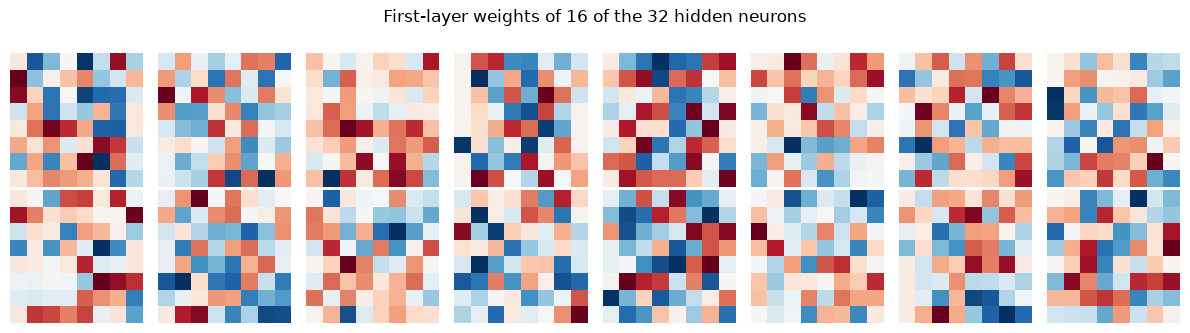

In [31]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for j, ax in enumerate(axes.ravel()):
    ax.imshow(mlp.coefs_[0][:, j].reshape(8, 8), cmap="RdBu_r")
    ax.axis("off")
plt.suptitle("First-layer weights of 16 of the 32 hidden neurons")
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

بیشتر این تصاویر شبیه نویزند و ساختار محدودی دارند (وزن‌های سنگین‌تر در مرکز که خطوط رقم واقعا آن‌جا هستند، وزن‌های ضعیف در حاشیه‌های همیشه‌خالی). دو نتیجه دقیق از این مشاهده:

۱. در یک شبکه متراکم کوچک، نورون‌های منفرد به‌ندرت با ویژگی‌های قابل‌تفسیر برای انسان متناظرند؛ اطلاعات کلاس **روی کل لایه توزیع شده است**. آشکارسازهای تمیز و تفسیرپذیر (لبه، خط) هم به وجود می‌آیند، اما در شبکه‌های بزرگ‌تر و در معماری‌های مخصوص تصویر (شبکه‌های پیچشی).

۲. معنای ملموس «جعبه سیاه» اسلایدها همین است: رفتار مدل در ۲۴۱۰ پارامتر درهم‌تنیده و بدون ساختار قابل‌خواندن کد شده؛ در تقابل با درخت تصمیم جلسه ۵ که می‌شد قاعده‌به‌قاعده چاپ و ممیزی‌اش کرد. تفسیرپذیری دقیقا به همین دلیل یک حوزه تحقیقاتی فعال است.

### ۷.۲ تحلیل خطا
روال استاندارد بعد از آموزش: بررسی تک‌تک نمونه‌های آزمون غلط‌دسته‌بندی‌شده.

</div>

غلط دسته‌بندی‌شده: 8 از 360


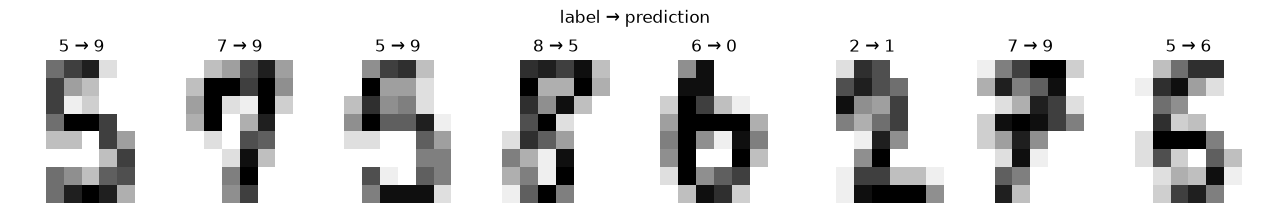

In [32]:
predictions = mlp.predict(X_test)
wrong = np.where(predictions != y_test)[0]
print("غلط دسته‌بندی‌شده:", len(wrong), "از", len(y_test))

fig, axes = plt.subplots(1, len(wrong), figsize=(1.6 * len(wrong), 2.2))
for ax, i in zip(axes, wrong):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"{y_test[i]} → {predictions[i]}")
    ax.axis("off")
plt.suptitle("label → prediction")
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

چند نمونه از این‌ها در وضوح ۸×۸ واقعا مبهم‌اند؛ مدلی که خطاهایش روی ورودی‌هایی متمرکز است که برای انسان هم دشوارند، رفتار معقولی دارد. در مقابل، خطاهای عجیب سیستماتیک روی ورودی‌های واضح نشانه مشکل در آموزش یا داده است.

</div>

<div dir="rtl" style="text-align:right">

### ۷.۳ تصاویر همراه با دسته‌بندی‌شان
روش استاندارد بازرسی یک دسته‌بند: گالری‌ای از ورودی‌ها همراه با کلاس پیش‌بینی‌شده و **اطمینان** مدل (بیشینه `predict_proba`). عنوان قرمز یعنی پیش‌بینی غلط:

</div>

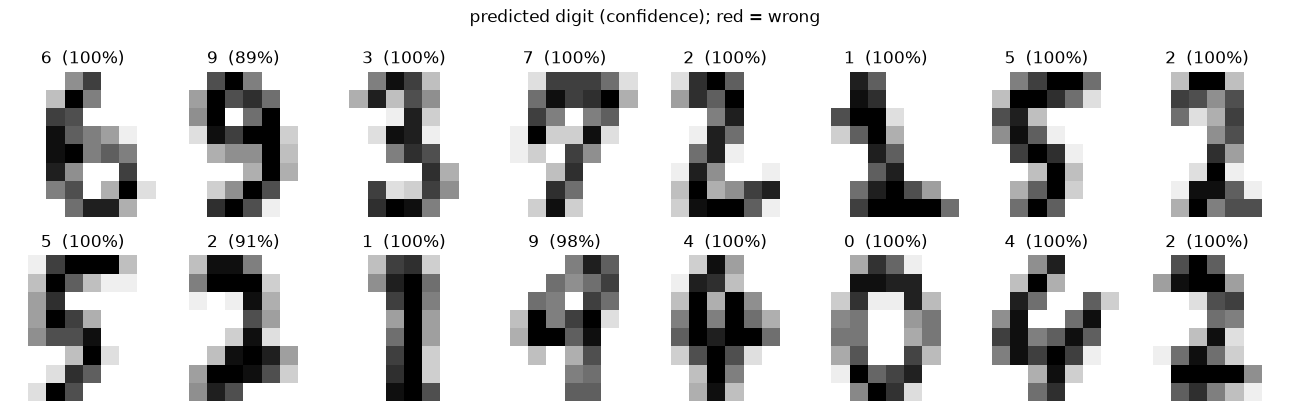

In [33]:
confidences = mlp.predict_proba(X_test).max(axis=1)

fig, axes = plt.subplots(2, 8, figsize=(13, 4.4))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    correct = predictions[i] == y_test[i]
    ax.set_title(f"{predictions[i]}  ({confidences[i]:.0%})",
                 color="black" if correct else "red")
    ax.axis("off")
plt.suptitle("predicted digit (confidence); red = wrong")
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

هر ۱۶ نمونه اول درست دسته‌بندی شده‌اند، اغلب با اطمینان نزدیک ۱۰۰٪؛ سازگار با دقت کلی ۹۷.۸٪. نمونه‌های جالب آن‌هایی‌اند که مدل درباره‌شان *مطمئن نیست*؛ تمرین همین‌ها را پیدا می‌کند.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۷: شبکه درباره چه چیزهایی مطمئن نیست؟
`confidences.argsort()` اندیس نمونه‌ها را از کم‌اطمینان‌ترین به مطمئن‌ترین مرتب می‌کند. **۱۶ نمونه کم‌اطمینان** مجموعه آزمون را با همان قالب گالری نمایش بده و بشمار چند تا از ۸ خطای بخش ۷.۲ میان آن‌ها هستند. قبل از اجرا فرضیه بساز: آیا اطمینان کم با غلط‌بودن رابطه دارد؟

</div>

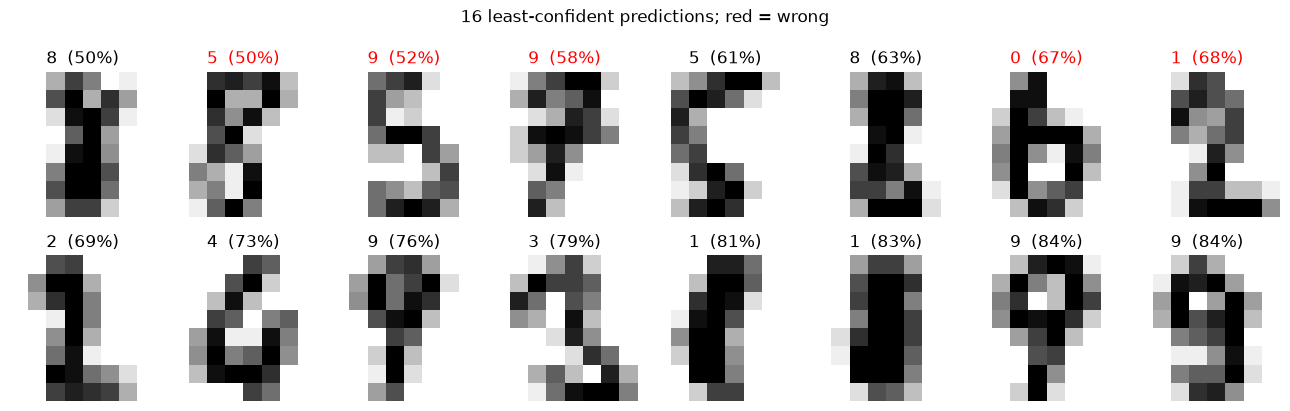

خطاها در میان ۱۶ نمونه کم‌اطمینان: 5 از ۸ خطای کل


In [34]:
# ✏️ ۱۶ پیش‌بینی کم‌اطمینان، با همان قالب گالری بالا
# راهنمایی: order = confidences.argsort()[:16]
order = confidences.argsort()[:16]

fig, axes = plt.subplots(2, 8, figsize=(13, 4.4))
for ax, i in zip(axes.ravel(), order):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    correct = predictions[i] == y_test[i]
    ax.set_title(f"{predictions[i]}  ({confidences[i]:.0%})",
                 color="black" if correct else "red")
    ax.axis("off")
plt.suptitle("16 least-confident predictions; red = wrong")
plt.tight_layout(); plt.show()

errors_here = sum(predictions[i] != y_test[i] for i in order)
print("خطاها در میان ۱۶ نمونه کم‌اطمینان:", errors_here, "از ۸ خطای کل")


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
order = confidences.argsort()[:16]

fig, axes = plt.subplots(2, 8, figsize=(13, 4.4))
for ax, i in zip(axes.ravel(), order):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    correct = predictions[i] == y_test[i]
    ax.set_title(f"{predictions[i]}  ({confidences[i]:.0%})",
                 color="black" if correct else "red")
    ax.axis("off")
plt.suptitle("16 least-confident predictions; red = wrong")
plt.tight_layout(); plt.show()

errors_here = sum(predictions[i] != y_test[i] for i in order)
print("خطاها در میان ۱۶ نمونه کم‌اطمینان:", errors_here, "از ۸ خطای کل")
```

**۵ تا از ۸ خطای کل** در همین ۱۶ نمونه پایینی از ۳۶۰ نمونه‌اند (اطمینان ۵۰ تا ۸۴٪، در برابر ~۱۰۰٪ معمول). عدد اطمینان واقعا اطلاع‌رسان است: عدم‌قطعیت شبکه دقیقا روی ورودی‌هایی متمرکز است که غلط می‌گیرد. سیستم‌های صنعتی مستقیما از همین استفاده می‌کنند و پیش‌بینی‌های کم‌اطمینان را برای بازبینی به انسان می‌سپارند.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۸: مقیاس بزرگ‌تر: CIFAR-10 با PyTorch

گام پایانی: یک محک استاندارد دسته‌بندی تصویر. **CIFAR-10** شامل ۶۰هزار عکس رنگی است (۳۲×۳۲ پیکسل، ۳ کانال رنگ) در ۱۰ کلاس (هواپیما، خودرو، پرنده، گربه، گوزن، سگ، قورباغه، اسب، کشتی، کامیون)؛ ۵۰هزار برای آموزش و ۱۰هزار برای آزمون.

در این مقیاس به **PyTorch** مهاجرت می‌کنیم، کتابخانه استاندارد شبکه‌های عصبی. تنسور PyTorch همان آرایه numpy است با دو افزودنی: **مشتق‌گیری خودکار** (محاسبات گذر رو به جلو را ثبت می‌کند و گذر رو به عقب را خودش استخراج می‌کند: همان جمله‌های δ بخش ۵، محاسبه‌شده به‌طور خودکار برای هر معماری) و **اجرا روی GPU** (اسلاید «چرا GPU»: میلیون‌ها ضرب‌وجمع مستقل به‌خوبی موازی می‌شوند). الگوریتم همان است؛ فقط پیاده‌سازی صنعتی است.

**در Colab** (بج بالای نوت‌بوک) همه‌چیز از قبل نصب است، دانلود روی اتصال گوگل چند ثانیه بیشتر طول نمی‌کشد، و فقط یک تنظیم مهم است: قبل از اجرا، GPU را از مسیر *Runtime ▸ Change runtime type ▸ T4 GPU* فعال کن تا سلول آموزش پایین خودکار روی آن اجرا شود. اولین اجرا مجموعه‌داده را دانلود می‌کند (حدود ۱۷۰ مگابایت، و بعد از آن کش می‌شود؛ در Kaggle گزینه *Internet* را در تنظیمات نوت‌بوک فعال کن):

</div>

In [38]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms

train_data = torchvision.datasets.CIFAR10(root="data", train=True, download=False,
                                          transform=transforms.ToTensor())
test_data = torchvision.datasets.CIFAR10(root="data", train=False, download=False,
                                         transform=transforms.ToTensor())

print("آموزش:", len(train_data), "| آزمون:", len(test_data))
print("کلاس‌ها:", train_data.classes)

آموزش: 50000 | آزمون: 10000
کلاس‌ها: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


<div dir="rtl" style="text-align:right">

یک نمونه از هر کلاس:

</div>

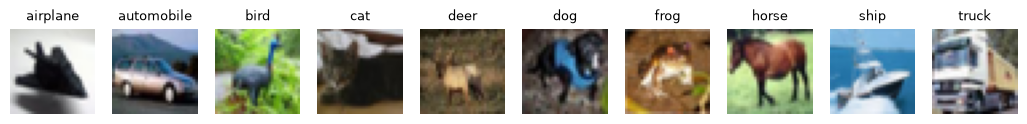

In [39]:
fig, axes = plt.subplots(1, 10, figsize=(13, 1.9))
for c, ax in enumerate(axes):
    idx = next(i for i, t in enumerate(train_data.targets) if t == c)
    ax.imshow(train_data.data[idx])
    ax.set_title(train_data.classes[c], fontsize=9)
    ax.axis("off")
plt.show()

<div dir="rtl" style="text-align:right">

### ۸.۱ مدل
هر تصویر پس از تخت‌شدن ۳ × ۳۲ × ۳۲ = **۳۰۷۲ ویژگی** می‌شود (همان خط لوله ارقام، با ورودی ۴۸ برابر). شبکه در PyTorch؛ به تناظر مستقیم توجه کن: `nn.Linear` همان $XW + b$ است، `nn.ReLU` همان فعال‌سازی بخش ۳، و ۱۰ خروجی همان امتیازهای کلاس‌ها (softmax داخل تابع هزینه اعمال می‌شود):

</div>

In [40]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),                # تصویر ۳×۳۲×۳۲ ← بردار ۳۰۷۲تایی
    nn.Linear(3072, 256),        # X @ W1 + b1
    nn.ReLU(),                   # فعال‌سازی
    nn.Linear(256, 10),          # ۱۰ امتیاز کلاس
)

n_params = sum(p.numel() for p in model.parameters())
print("تعداد پارامترهای قابل‌آموزش:", n_params)

تعداد پارامترهای قابل‌آموزش: 789258


<div dir="rtl" style="text-align:right">

### ۸.۲ حلقه آموزش
خط‌به‌خط، همان `train_network` بخش ۵ است:

| بخش ۵ (numpy) | PyTorch |
|---|---|
| `H = sigmoid(X @ W1 + b1)` و `out = ...` | `scores = model(images)` |
| هزینه از `out - y` | `loss = loss_fn(scores, labels)` |
| `delta_out` و `delta_hidden` با استخراج دستی | `loss.backward()` (مشتق‌گیری خودکار) |
| `W -= learning_rate * gradient` | `optimizer.step()` |

دو تطبیق برای مقیاس، هر دو رویه استاندارد:

- **مینی‌بچ:** به‌جای کل داده در هر گام، گرادیان روی بچ‌های ۱۲۸تایی محاسبه می‌شود (گرادیان کاهشی تصادفی): ۳۹۱ به‌روزرسانی پارامتر در هر ایپاک به‌جای یکی.
- بهینه‌ساز **Adam**: رایج‌ترین واریانت گرادیان کاهشی (جدول بخش ۹). همان قاعده (گام در خلاف جهت گرادیان) اما با اندازه گام خودتنظیم برای هر پارامتر، که این‌جا بسیار سریع‌تر از SGD ساده همگرا می‌شود.

</div>

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"   # اگر GPU هست، از آن استفاده کن
print("پردازنده:", device)

model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

for epoch in range(20):
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        scores = model(images)               # گذر رو به جلو
        loss = loss_fn(scores, labels)       # هزینه
        optimizer.zero_grad()
        loss.backward()                      # پس‌انتشار (خودکار)
        optimizer.step()                     # گام گرادیان کاهشی
        total_loss += loss.item() * len(labels)
    print(f"epoch {epoch + 1:2d} | mean loss {total_loss / len(train_data):.3f}")

پردازنده: cpu
epoch  1 | mean loss 1.889
epoch  2 | mean loss 1.722
epoch  3 | mean loss 1.648
epoch  4 | mean loss 1.592
epoch  5 | mean loss 1.557
epoch  6 | mean loss 1.527
epoch  7 | mean loss 1.503
epoch  8 | mean loss 1.482
epoch  9 | mean loss 1.464
epoch 10 | mean loss 1.445
epoch 11 | mean loss 1.433
epoch 12 | mean loss 1.421
epoch 13 | mean loss 1.402
epoch 14 | mean loss 1.390
epoch 15 | mean loss 1.390
epoch 16 | mean loss 1.375
epoch 17 | mean loss 1.363
epoch 18 | mean loss 1.360
epoch 19 | mean loss 1.346
epoch 20 | mean loss 1.340


<div dir="rtl" style="text-align:right">

### ۸.۳ ارزیابی

</div>

In [42]:
test_loader = DataLoader(test_data, batch_size=512)

correct = 0
with torch.no_grad():                        # در زمان آزمون گرادیان لازم نیست
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(dim=1).cpu()
        correct += (preds == labels).sum().item()

print("دقت آزمون:", round(correct / len(test_data), 3))

دقت آزمون: 0.495


<div dir="rtl" style="text-align:right">

نقاط مرجع برای این عدد:

| مدل | دقت آزمون CIFAR-10 |
|---|---|
| حدس تصادفی | ۰.۱۰ |
| **همین MLP (۷۹۰هزار پارامتر)** | **≈ ۰.۵** |
| انسان | ≈ ۰.۹۴ |
| شبکه‌های پیچشی | ≈ ۰.۹۹ |

هر دو خوانش هم‌زمان درست‌اند. پنج برابر شانس، آموخته‌شده فقط از پیکسل‌ها: سازوکار مقیاس‌پذیر است. و بسیار پایین‌تر از سطح انسان، چون لایه متراکم ۳۰۷۲ ورودی‌اش را فهرستی بدون ترتیب می‌بیند: مفهومی از همسایگی دو پیکسل ندارد، پس شیئی که چند پیکسل جابه‌جا شود بردار ورودی کاملا متفاوتی می‌سازد. بستن این فاصله معماری‌هایی می‌خواهد که ساختار مکانی را در خود دارند: **شبکه‌های پیچشی**، گام استاندارد بعد از این نوت‌بوک.

چند تصویر آزمون با پیش‌بینی مدل:

</div>

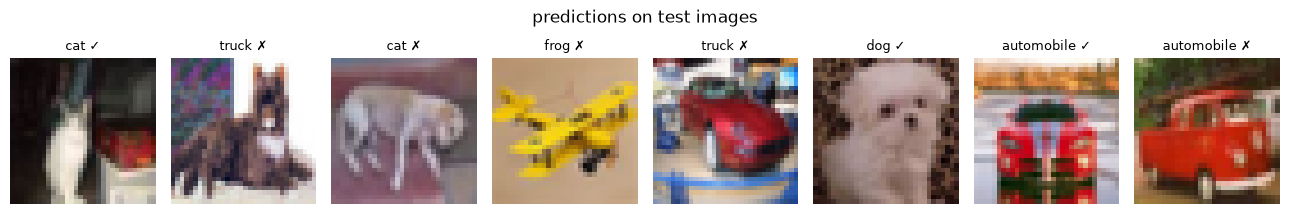

In [43]:
images, labels = next(iter(DataLoader(test_data, batch_size=8, shuffle=True,
                                      generator=torch.Generator().manual_seed(0))))
with torch.no_grad():
    preds = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, img, p, t in zip(axes, images, preds, labels):
    ax.imshow(img.permute(1, 2, 0))          # تنسور (3,32,32) ← تصویر (32,32,3)
    mark = "✓" if p == t else "✗"
    ax.set_title(f"{test_data.classes[p]} {mark}", fontsize=9)
    ax.axis("off")
plt.suptitle("predictions on test images")
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۸: دقت به تفکیک کلاس
دقت کلی، ساختار را پنهان می‌کند. دقت را برای هر یک از ۱۰ کلاس جداگانه محاسبه کن و مشخص کن مدل در کدام کلاس‌ها ضعیف‌ترین است. اول فرضیه بساز: عکس‌های کدام کلاس‌ها بیشترین تنوع را در زاویه و پس‌زمینه دارند؟

</div>

In [44]:
# ✏️ دقت به تفکیک کلاس
# راهنمایی: پیش‌بینی کل مجموعه آزمون را جمع کن؛ بعد برای هر کلاس c:
#           accuracy_c = میانگین (predictions == c) روی نمونه‌هایی که برچسبشان c است
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        all_preds.append(model(images.to(device)).argmax(dim=1).cpu())
        all_labels.append(labels)
preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

for c, name in enumerate(test_data.classes):
    mask = labels == c
    print(f"{name:12s} {(preds[mask] == c).float().mean():.2f}")


airplane     0.47
automobile   0.64
bird         0.30
cat          0.31
deer         0.31
dog          0.32
frog         0.72
horse        0.61
ship         0.62
truck        0.65


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        all_preds.append(model(images.to(device)).argmax(dim=1).cpu())
        all_labels.append(labels)
preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

for c, name in enumerate(test_data.classes):
    mask = labels == c
    print(f"{name:12s} {(preds[mask] == c).float().mean():.2f}")
```

نتیجه معمول: **کشتی (~۰.۷۲) و کامیون و خودرو (~۰.۶) در بالا؛ پرنده، گربه، گوزن و هواپیما (~۰.۳۵) در پایین**. وسایل نقلیه صلب که در جهت‌گیری‌های یکنواخت و پس‌زمینه‌های ساده عکاسی شده‌اند برای شبکه متراکم بی‌خبر از مکان آسان‌ترین‌اند؛ حیوانات تغییرشکل‌پذیر در زاویه‌ها و صحنه‌های متنوع سخت‌ترین. به ارزش محاسبه واقعی به‌جای حدس هم توجه کن: قورباغه دقت بالایی می‌گیرد (پس‌زمینه‌های سبز یکدست) و هواپیما دقت پایین؛ چیزی که حدس «وسیله نقلیه در برابر حیوان» از دستش می‌داد. دقت به‌تفکیک کلاس اولین ابزار تشخیصی استاندارد برای هر دسته‌بند است: درس جلسه ۵ (خطاها را بررسی کن) در مقیاس مجموعه‌داده.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۹: جمع‌بندی و گام‌های بعدی

اشتراک پیاده‌سازی امروز با مدل‌های مقیاس صنعتی:

| | این نوت‌بوک | مدل‌های بزرگ (کلاس GPT) |
|---|---|---|
| عمل نورون | جمع وزن‌دار + فعال‌سازی | جمع وزن‌دار + فعال‌سازی |
| سیگنال آموزش | گرادیان تابع هزینه | گرادیان تابع هزینه |
| محاسبه گرادیان | پس‌انتشار | پس‌انتشار |
| بهینه‌ساز | گرادیان کاهشی | واریانت‌های گرادیان کاهشی (Adam و…) |
| پارامترها | **۲۴۱۰ تا ۷۸۹٬۲۵۸** | **بیش از ۱۰¹²** |
| عمق | ۱ لایه پنهان | ده‌ها تا صدها لایه |

چهار سطر اول یکسان‌اند؛ «یادگیری عمیق» یعنی مقیاس‌دادن به دو سطر آخر. عمق به لایه‌های متوالی اجازه می‌دهد ویژگی‌های انتزاعی‌تر بسازند (سلسله‌مراتب لبه ← اجزا ← شیء اسلایدها)، و در مقیاس بزرگ همین سازوکار پشت تشخیص چهره، تصویربرداری پزشکی، تشخیص گفتار و مدل‌های زبانی است.

محدودیت‌های شناخته‌شده، که همگی در این نوت‌بوک یا اسلایدها دیده شدند: نیاز سنگین به داده (بخش ۸: ۵۰هزار تصویر برای دقتی نزدیک ۰.۵)، هزینه بالای آموزش در مقیاس بزرگ، تفسیرپذیری محدود (بخش ۷.۱)، و به‌ارث‌بردن سوگیری‌های موجود در داده آموزش (جلسه ۱).

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۹: تکلیف
**الف. playground.tensorflow.org** (در مرورگر، بدون نصب): نتایج امروز را تعاملی بازتولید کن:

۱. داده دایره‌ای، بدون لایه پنهان ← شکست بخش ۵.۱.

۲. یک لایه پنهان با ۴ نورون اضافه کن ← نتیجه بخش ۵.۴؛ نشانگر را روی هر نورون نگه دار تا مرز خطی آموخته‌اش را ببینی، مثل نمودارهای فعال‌سازی ما.

۳. نرخ یادگیری را روی بیشینه بگذار ← نوسان تمرین ۴.

**ب. Kaggle**: مسابقه [Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer) همین مسئله امروز است روی تصاویر ۲۸×۲۸. ترکیب `MLPClassifier` و روال Kaggle جلسه ۵ یک ارسال اول قابل‌قبول می‌دهد.

*جلسه بعد: به‌کارگیری شبکه‌ها برای زبان، مسیر مدل‌های زبانی امروزی.*

</div>

<div dir="rtl" style="text-align:right">

---
# جمع‌بندی

مطالب امروز: نورون مصنوعی (جمع وزن‌دار، بایاس، فعال‌سازی)؛ نورون در نقش دروازه منطقی؛ جداپذیری خطی و محدودیت XOR (مینسکی و پپرت، ۱۹۶۹)؛ سیگموید و ضرورت مشتق‌پذیری برای آموزش گرادیانی؛ آموزش یک نورون با گرادیان کاهشی همراه با مرز تصمیم و منحنی هزینه؛ لایه پنهان و پس‌انتشار خطا با پیاده‌سازی کامل؛ حل داده هم‌مرکز و XOR با شبکه دولایه؛ دسته‌بندی ارقام با دقت ۹۷.۸٪ و ۲۴۱۰ پارامتر؛ نمایش وزن‌ها و تحلیل خطا؛ و در پایان CIFAR-10 با PyTorch: شبکه‌ای ۷۸۹هزار پارامتری با دقت ≈۵۰٪ روی عکس‌های واقعی، که هم مقیاس‌پذیری این سازوکار را نشان داد و هم دلیل نیاز به معماری‌های مخصوص تصویر را.

نکته مرکزی: شبکه عصبی یک تابع مشتق‌پذیر است که پارامترهایش با گرادیان کاهشی روی تابع هزینه تنظیم می‌شوند؛ همان بهینه‌سازی جلسه ۴، در مقیاس بزرگ‌تر. از حلقه numpy تا PyTorch تا مدل‌های صنعتی، فقط پیاده‌سازی عوض می‌شود. 🎉

</div>